
### MEMBER 1 — Problem Understanding & Data Structure
###

# IT3051 — Fundamentals of Data Mining
## Mini Project: E-Commerce Customer Churn Prediction

**Project Title:** Predicting Customer Churn in E-Commerce Using Demographic,
Behavioral, and Transactional Data

**Problem Statement:** Can a customer's demographic profile, in-app behavior,
order preferences, and transaction history predict whether they will stop
purchasing from an online retail platform? This project builds a binary
classification model to predict customer churn, giving retailers a way to
flag at-risk customers before they disengage rather than after. Predicting
churn matters because acquiring a new customer typically costs several times
more than retaining an existing one, making early identification of at-risk
customers directly valuable to the business.

**Target Users:** E-commerce businesses, online retailers, marketplace
sellers, and marketing/retention teams.

**Dataset:** "E-Commerce Dataset" (Kaggle, Anagha Paul) — 5,630 customer
records, 20 raw attributes. Key features include `Tenure` (months as a
customer), `Complain` (whether the customer has filed a complaint),
`CashbackAmount` (total cashback received), `DaySinceLastOrder` (recency of
last purchase), `SatisfactionScore`, and `PreferedOrderCat` (preferred
product category), alongside demographic fields (Gender, MaritalStatus,
CityTier) and additional transactional/behavioral fields. The target
variable is `Churn` (1 = customer churned, 0 = customer retained).

#Install Kaggle

In [ ]:
!pip install -q kaggle

In [ ]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Enter your Kaggle API token: ")

Enter your Kaggle API token: ··········


In [ ]:
!kaggle datasets download -d anaghapaul/e-commerce-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/anaghapaul/e-commerce-dataset
License(s): CC0-1.0
100% 90.7k/90.7k [00:00<00:00, 51.2MB/s]



In [ ]:
import os

os.listdir()

['.config', 'E-Commerce Churn Data.csv', 'sample_data']

In [ ]:
import glob

glob.glob("*.csv")

['E-Commerce Churn Data.csv']

#Loading the Data and importing all the necessary libiries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("E-Commerce Churn Data.csv")
pd.set_option('display.max_columns', None)

#Basic shape and structure

In [ ]:
#rows, columns
print(df.shape)
#dtypes + non-null counts per column
print(df.info())
df.head()

(5630, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberO

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


Consists of 3 data types: integer, float, and objects

#Separate numeric vs categorical columns

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# drop identifier and target from the numeric feature list for plotting
numeric_features = [c for c in numeric_cols if c not in ['CustomerID', 'Churn']]

print("Numeric:", numeric_features)
print("Categorical:", categorical_cols)

Numeric: ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
Categorical: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


#Summary statistics for numeric columns

In [ ]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure,5366.0,10.189899,8.557241,0.0,2.0,9.0,16.0,61.0
CityTier,5630.0,1.654707,0.915389,1.0,1.0,1.0,3.0,3.0
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.0,14.0,20.0,127.0
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.0,3.0,3.0,5.0
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.0,4.0,4.0,6.0
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.0,3.0,4.0,5.0
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.0,3.0,6.0,22.0
Complain,5630.0,0.284902,0.451408,0.0,0.0,0.0,1.0,1.0
OrderAmountHikeFromlastYear,5365.0,15.707922,3.675485,11.0,13.0,15.0,18.0,26.0
CouponUsed,5374.0,1.751023,1.894621,0.0,1.0,1.0,2.0,16.0


#Distribution plots for every numeric column (histograms)

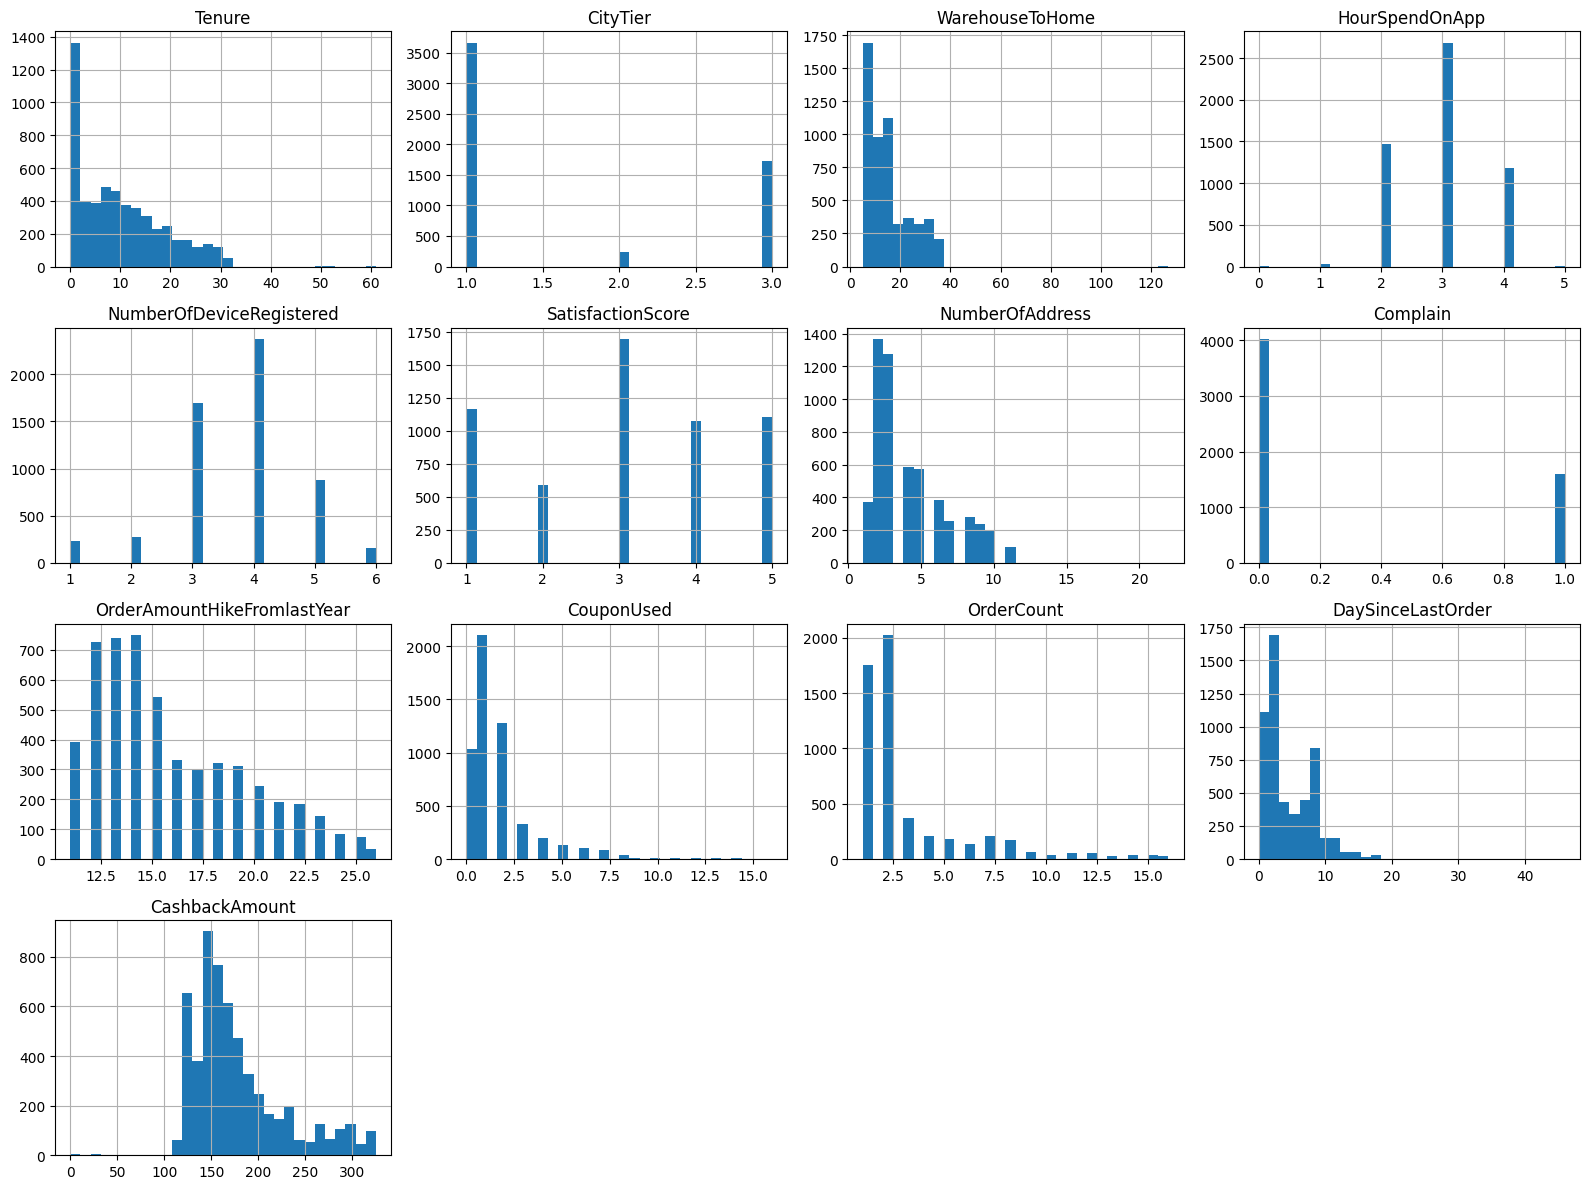

In [ ]:
df[numeric_features].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

In [ ]:
skewness = df[numeric_features].skew().sort_values(ascending=False)
print(skewness)

CouponUsed                     2.545653
OrderCount                     2.196414
WarehouseToHome                1.619154
DaySinceLastOrder              1.191000
CashbackAmount                 1.149595
NumberOfAddress                1.088639
Complain                       0.953347
OrderAmountHikeFromlastYear    0.790785
Tenure                         0.736513
CityTier                       0.735326
HourSpendOnApp                -0.027213
SatisfactionScore             -0.142626
NumberOfDeviceRegistered      -0.396969
dtype: float64


In [ ]:
skew_df = pd.DataFrame({
    'skewness': df[numeric_features].skew()
}).sort_values('skewness', ascending=False)

skew_df['recommended_imputation'] = skew_df['skewness'].apply(
    lambda x: 'median' if abs(x) > 0.5 else 'mean'
)
print(skew_df)

                             skewness recommended_imputation
CouponUsed                   2.545653                 median
OrderCount                   2.196414                 median
WarehouseToHome              1.619154                 median
DaySinceLastOrder            1.191000                 median
CashbackAmount               1.149595                 median
NumberOfAddress              1.088639                 median
Complain                     0.953347                 median
OrderAmountHikeFromlastYear  0.790785                 median
Tenure                       0.736513                 median
CityTier                     0.735326                 median
HourSpendOnApp              -0.027213                   mean
SatisfactionScore           -0.142626                   mean
NumberOfDeviceRegistered    -0.396969                   mean


#Distribution plots for every categorical column (bar charts)

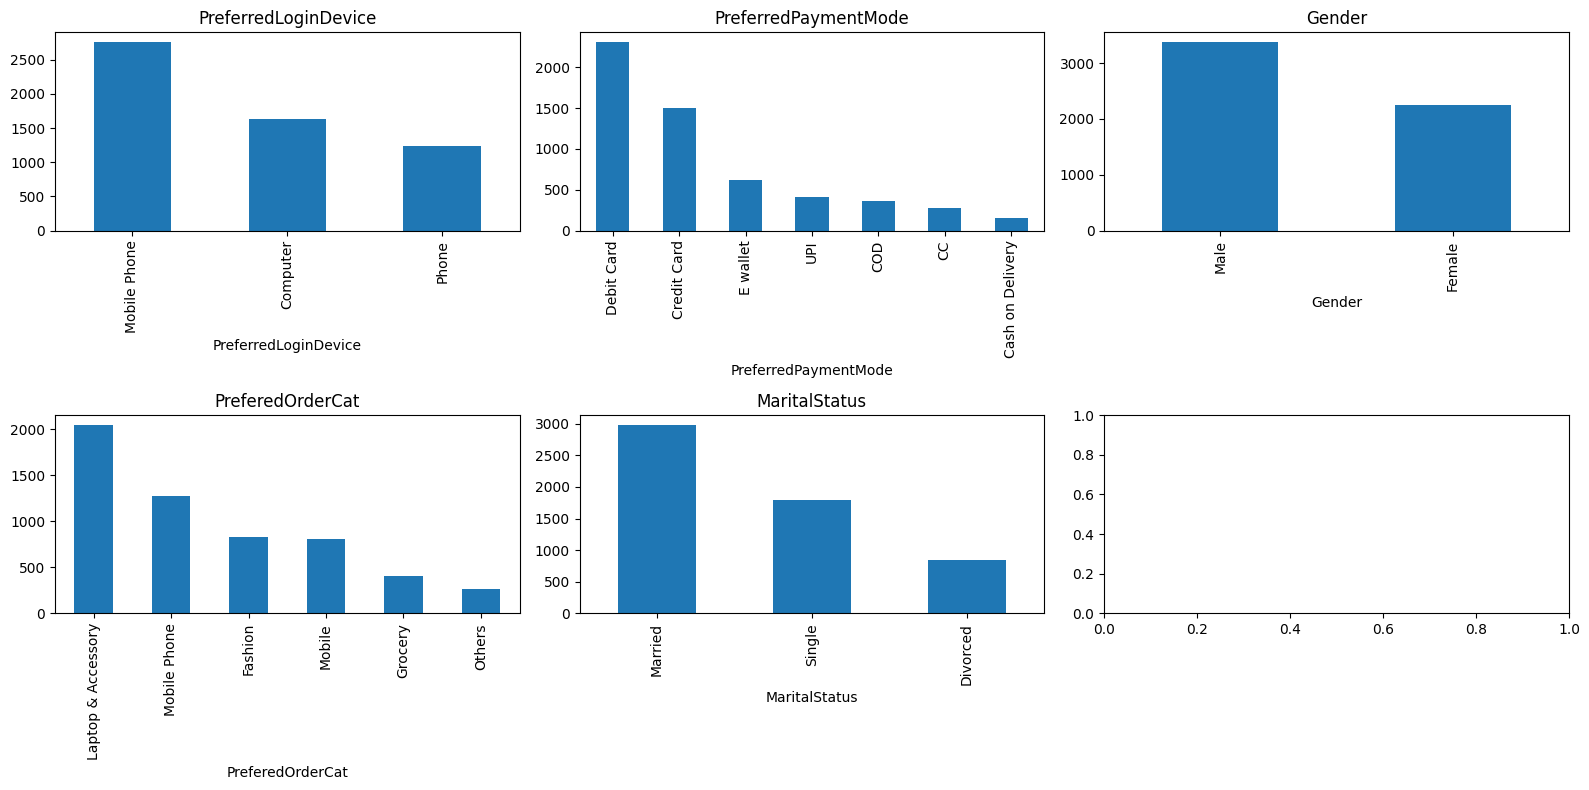

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- PreferredLoginDevice ---
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

--- PreferredPaymentMode ---
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

--- Gender ---
Gender
Male      3384
Female    2246
Name: count, dtype: int64

--- PreferedOrderCat ---
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

--- MaritalStatus ---
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


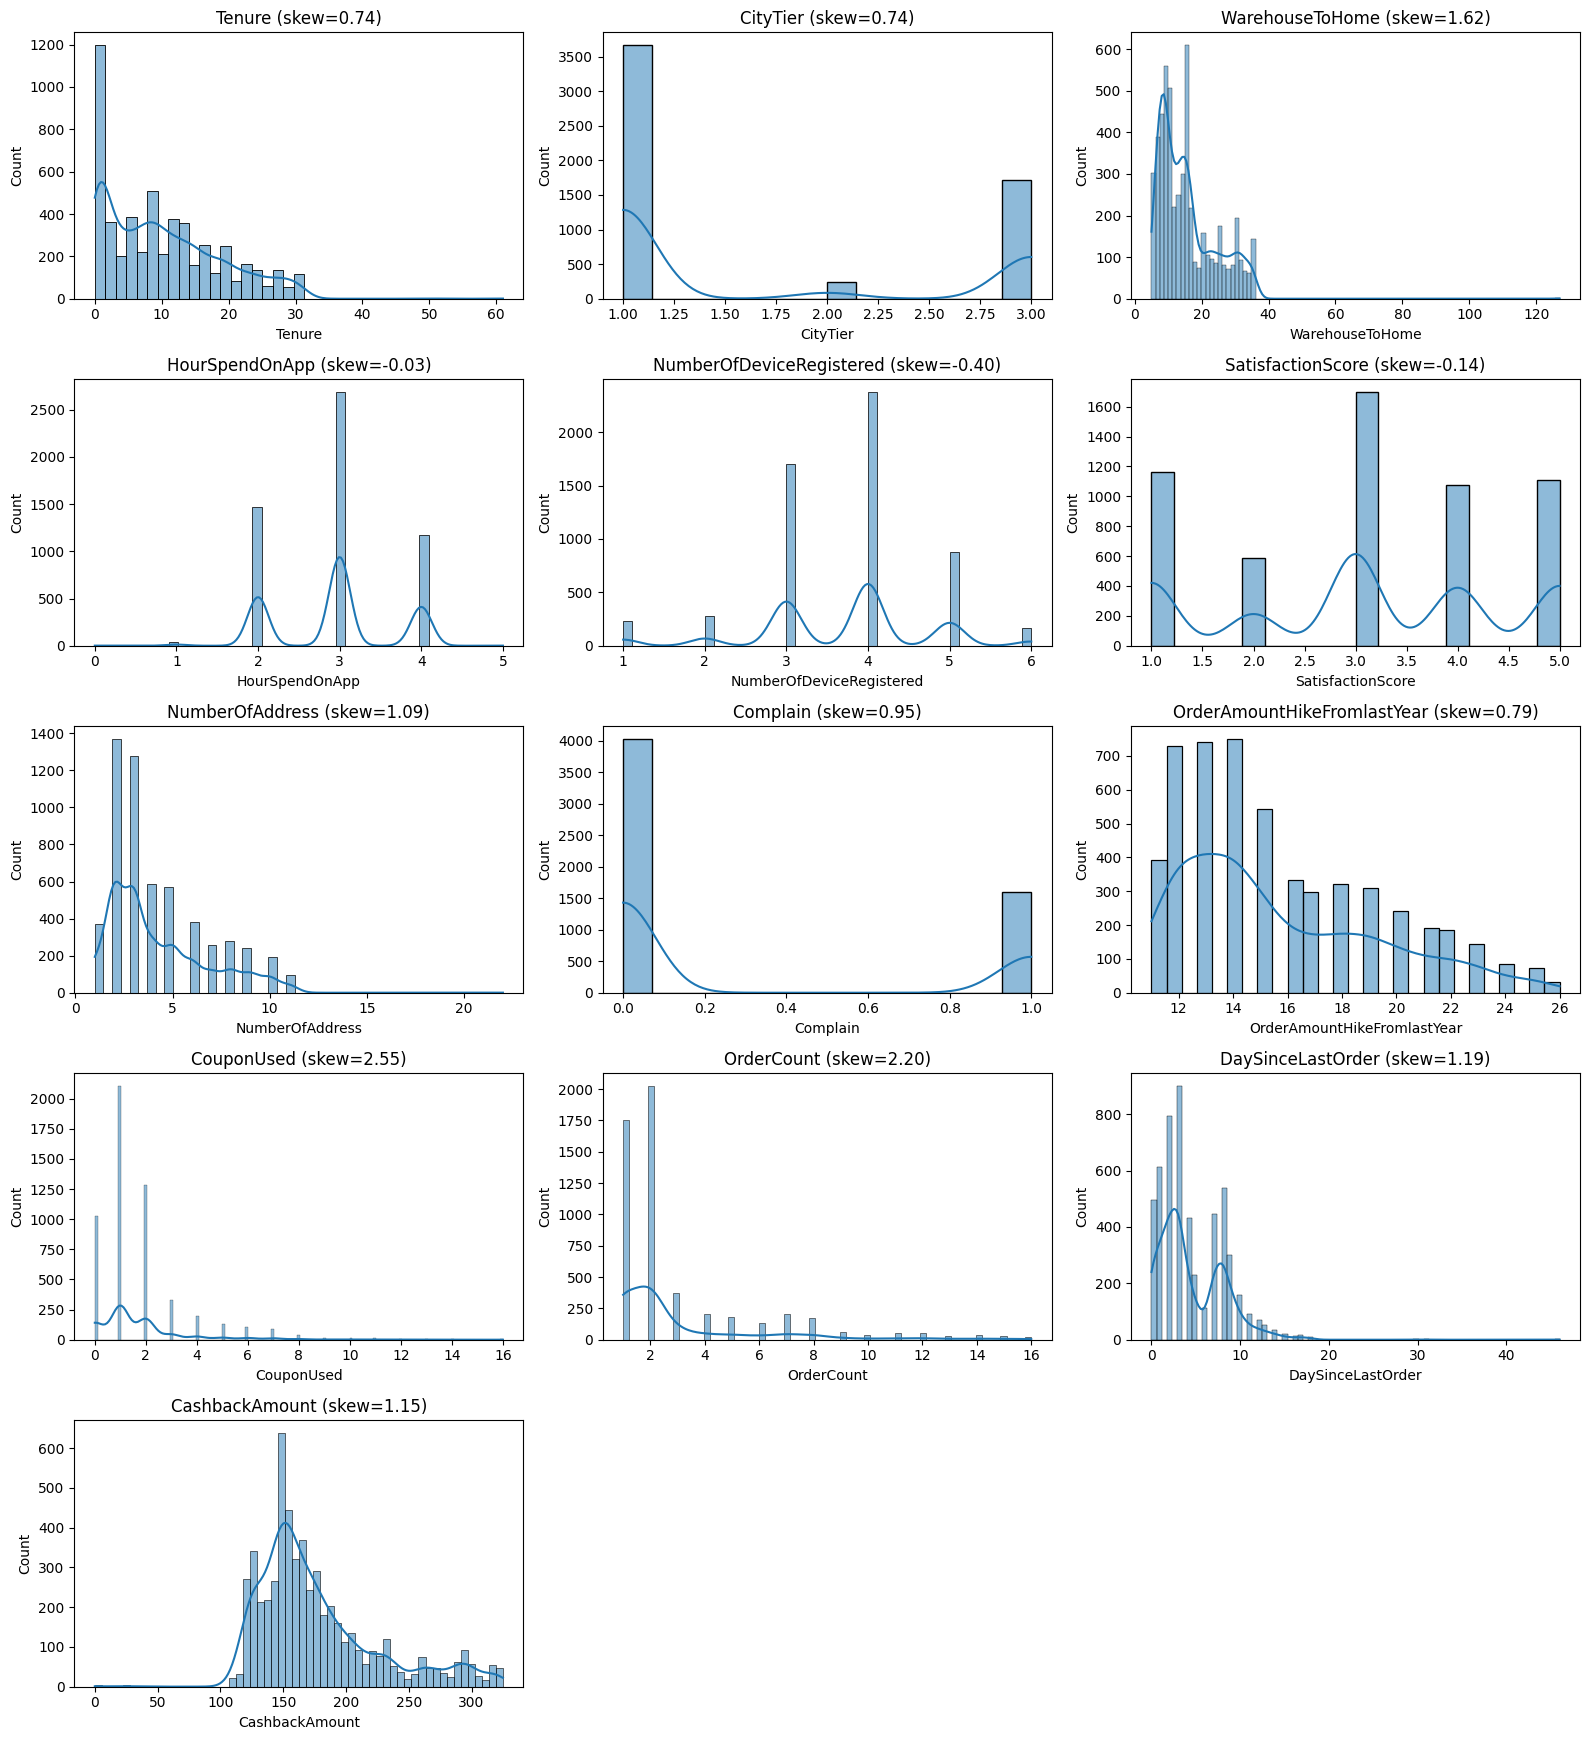

In [ ]:
import math

n = len(numeric_features)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f"{col} (skew={df[col].skew():.2f})")


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#Checking ordinal-looking numeric columns separately

###
### MEMBER 2 SECTION — Missing Values & MNAR Finding
###

In [ ]:
print(df['CityTier'].value_counts().sort_index())
print(df['SatisfactionScore'].value_counts().sort_index())

CityTier
1    3666
2     242
3    1722
Name: count, dtype: int64
SatisfactionScore
1    1164
2     586
3    1698
4    1074
5    1108
Name: count, dtype: int64


#Target variable distribution

Churn
0    4682
1     948
Name: count, dtype: int64
Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64


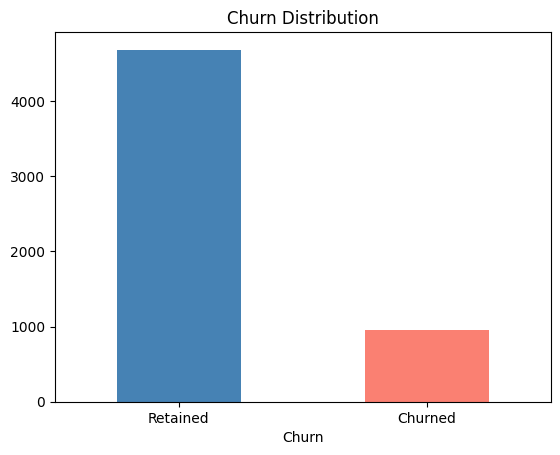

In [ ]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xticks([0, 1], ['Retained', 'Churned'], rotation=0)
plt.show()

#Missing-value investigation

Check for exact missing counts and percentages

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct.round(2)
})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)
print(missing_df)


                             missing_count  missing_pct
DaySinceLastOrder                      307         5.45
OrderAmountHikeFromlastYear            265         4.71
Tenure                                 264         4.69
OrderCount                             258         4.58
CouponUsed                             256         4.55
HourSpendOnApp                         255         4.53
WarehouseToHome                        251         4.46


Checking whether missingness overlaps across rows

In [ ]:
missing_cols = missing_df.index.tolist()

# how many missing fields does each row have?
df['missing_field_count'] = df[missing_cols].isnull().sum(axis=1)
print(df['missing_field_count'].value_counts().sort_index())

missing_field_count
0    3774
1    1856
Name: count, dtype: int64


checking does missingness correlate with churn

In [ ]:
for col in missing_cols:
    df[f'{col}_is_missing'] = df[col].isnull()
    churn_rate = df.groupby(f'{col}_is_missing')['Churn'].mean() * 100
    print(f"\n{col} — churn rate by missing status:")
    print(churn_rate)


DaySinceLastOrder — churn rate by missing status:
DaySinceLastOrder_is_missing
False    16.795040
True     17.589577
Name: Churn, dtype: float64

OrderAmountHikeFromlastYear — churn rate by missing status:
OrderAmountHikeFromlastYear_is_missing
False    17.409133
True      5.283019
Name: Churn, dtype: float64

Tenure — churn rate by missing status:
Tenure_is_missing
False    16.157287
True     30.681818
Name: Churn, dtype: float64

OrderCount — churn rate by missing status:
OrderCount_is_missing
False    17.311988
True      6.976744
Name: Churn, dtype: float64

CouponUsed — churn rate by missing status:
CouponUsed_is_missing
False    17.491626
True      3.125000
Name: Churn, dtype: float64

HourSpendOnApp — churn rate by missing status:
HourSpendOnApp_is_missing
False    16.558140
True     22.745098
Name: Churn, dtype: float64

WarehouseToHome — churn rate by missing status:
WarehouseToHome_is_missing
False    16.062465
True     33.466135
Name: Churn, dtype: float64


## Feature Engineering: Missing-Value Indicators

Earlier analysis showed that missingness in 6 of the 7 affected columns is not random —
it correlates with churn rate:

- Tenure: 16.2% churn (present) vs 30.7% (missing)
- WarehouseToHome: 16.1% vs 33.5%
- HourSpendOnApp: 16.6% vs 22.7%
- OrderAmountHikeFromlastYear: 17.4% vs 5.3%
- OrderCount: 17.3% vs 7.0%
- CouponUsed: 17.5% vs 3.1%

This is evidence of MNAR (Missing Not At Random) — the fact that a value is missing
carries information about churn, separate from the value itself. Dropping this signal
during imputation would throw away useful predictive information.

To preserve it, a binary "was_missing" indicator is created for each of these 6 columns
before imputation. DaySinceLastOrder is excluded from this step since its missingness
showed no meaningful difference in churn rate (16.8% vs 17.6%), so no indicator is needed
for it.

In [ ]:
for col in ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'OrderAmountHikeFromlastYear', 'OrderCount', 'CouponUsed']:
    df[f'{col}_was_missing'] = df[col].isnull().astype(int)

## Duplicate Row Detection

Checking for fully duplicated rows in the dataset, to confirm each record
represents a distinct customer observation.

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

duplicate_ids = df['CustomerID'].duplicated().sum()
print(f"Number of duplicate CustomerIDs: {duplicate_ids}")

Number of duplicate rows: 0
Number of duplicate CustomerIDs: 0


No duplicate rows or duplicate CustomerIDs were found, confirming each row
represents a unique customer with no repeated observations.

#Churn relationships

### ==========================================================================
### MEMBER 3 SECTION — Churn Relationships & Business Insights
### ==========================================================================

Churn rate by each categorical feature

In [ ]:
categorical_cols_for_churn = ['Gender', 'MaritalStatus', 'PreferredPaymentMode',
                               'PreferredLoginDevice', 'PreferedOrderCat', 'CityTier']

for col in categorical_cols_for_churn:
    print(f"\n--- Churn rate by {col} ---")
    print((df.groupby(col)['Churn'].mean() * 100).round(2).sort_values(ascending=False))


--- Churn rate by Gender ---
Gender
Male      17.73
Female    15.49
Name: Churn, dtype: float64

--- Churn rate by MaritalStatus ---
MaritalStatus
Single      26.73
Divorced    14.62
Married     11.52
Name: Churn, dtype: float64

--- Churn rate by PreferredPaymentMode ---
PreferredPaymentMode
COD                 28.77
E wallet            22.80
CC                  21.61
UPI                 17.39
Cash on Delivery    15.44
Debit Card          15.38
Credit Card         12.86
Name: Churn, dtype: float64

--- Churn rate by PreferredLoginDevice ---
PreferredLoginDevice
Phone           22.42
Computer        19.83
Mobile Phone    12.59
Name: Churn, dtype: float64

--- Churn rate by PreferedOrderCat ---
PreferedOrderCat
Mobile Phone          27.54
Mobile                27.19
Fashion               15.50
Laptop & Accessory    10.24
Others                 7.58
Grocery                4.88
Name: Churn, dtype: float64

--- Churn rate by CityTier ---
CityTier
3    21.37
2    19.83
1    14.51
Name: Chu

## Data Quality Fix: Category Consolidation

Initial churn-rate-by-category analysis revealed inconsistent labeling for the same
category in three columns — likely from different data entry sources or manual
correction over time:

- PreferredLoginDevice: "Phone" and "Mobile Phone" were the same device type
- PreferredPaymentMode: "COD"/"Cash on Delivery" and "CC"/"Credit Card" were each
  the same payment method
- PreferedOrderCat: "Mobile" and "Mobile Phone" were the same category

Before consolidation, these split categories showed misleadingly large churn-rate
gaps within what was actually a single group (e.g. "COD" at 28.77% vs "Cash on
Delivery" at 15.44% churn). Categories were merged using the labels below, and
the churn-by-category analysis was re-run on the corrected data.

**Findings (post-consolidation):**

- MaritalStatus: Single customers churn more than twice as often as Married
  customers (26.73% vs 11.52%)
- PreferedOrderCat: Mobile Phone category buyers churn far more than Grocery
  buyers (27.40% vs 4.88%)
- CityTier: churn rises monotonically with tier — 14.51% (Tier 1) → 19.83%
  (Tier 2) → 21.37% (Tier 3)
- PreferredPaymentMode: Cash on Delivery and E-wallet users churn nearly twice
  as often as Credit/Debit Card users (24.90% / 22.80% vs 14.21% / 15.38%)
- PreferredLoginDevice: Computer users churn somewhat more than Mobile Phone
  users (19.83% vs 15.62%)
- Gender: minimal difference (17.73% vs 15.49%), not a strong standalone driver

In [ ]:
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})

df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'COD': 'Cash on Delivery',
    'CC': 'Credit Card'
})

df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

In [ ]:
categorical_cols_for_churn = ['Gender', 'MaritalStatus', 'PreferredPaymentMode',
                               'PreferredLoginDevice', 'PreferedOrderCat', 'CityTier']

for col in categorical_cols_for_churn:
    print(f"\n--- Churn rate by {col} ---")
    print((df.groupby(col)['Churn'].mean() * 100).round(2).sort_values(ascending=False))


--- Churn rate by Gender ---
Gender
Male      17.73
Female    15.49
Name: Churn, dtype: float64

--- Churn rate by MaritalStatus ---
MaritalStatus
Single      26.73
Divorced    14.62
Married     11.52
Name: Churn, dtype: float64

--- Churn rate by PreferredPaymentMode ---
PreferredPaymentMode
Cash on Delivery    24.90
E wallet            22.80
UPI                 17.39
Debit Card          15.38
Credit Card         14.21
Name: Churn, dtype: float64

--- Churn rate by PreferredLoginDevice ---
PreferredLoginDevice
Computer        19.83
Mobile Phone    15.62
Name: Churn, dtype: float64

--- Churn rate by PreferedOrderCat ---
PreferedOrderCat
Mobile Phone          27.40
Fashion               15.50
Laptop & Accessory    10.24
Others                 7.58
Grocery                4.88
Name: Churn, dtype: float64

--- Churn rate by CityTier ---
CityTier
3    21.37
2    19.83
1    14.51
Name: Churn, dtype: float64


Churn rate by Complain

In [ ]:
print(df.groupby('Complain')['Churn'].mean() * 100)

Complain
0    10.928962
1    31.670823
Name: Churn, dtype: float64


Churn rate by SatisfactionScore

In [ ]:
print(df.groupby('SatisfactionScore')['Churn'].mean() * 100)

SatisfactionScore
1    11.512027
2    12.627986
3    17.196702
4    17.132216
5    23.826715
Name: Churn, dtype: float64


## Churn Relationship: SatisfactionScore (counterintuitive finding)

Churn rate increases with satisfaction score — the opposite of what would
normally be expected:
- Score 1: 11.51% churn
- Score 2: 12.63% churn
- Score 3: 17.20% churn
- Score 4: 17.13% churn
- Score 5: 23.83% churn

This is a genuinely unexpected pattern rather than noise, since it's consistent
across the scale. Possible explanations to investigate further: the scale's
direction may not follow the intuitive assumption (1=best), or self-reported
satisfaction may not reliably predict actual retention behavior in this dataset.
This will be checked against the dataset's documentation and cross-tabulated
against Complain before drawing firm conclusions.

In [ ]:
pd.crosstab(df['SatisfactionScore'], df['Complain'], normalize='index') * 100

Complain,0,1
SatisfactionScore,,
1,68.041237,31.958763
2,70.989761,29.010239
3,72.202591,27.797409
4,75.046555,24.953445
5,70.938628,29.061372


The direction of the SatisfactionScore scale could not be confirmed from
available dataset documentation. The counterintuitive relationship with churn
(higher scores → higher churn) is reported as observed, with scale-direction
ambiguity noted as a limitation. This should not materially affect model
performance, since the model will learn whatever relationship the data
actually encodes — but it does affect how the finding should be interpreted
and communicated to stakeholders.

Visualize the strongest ones as bar charts

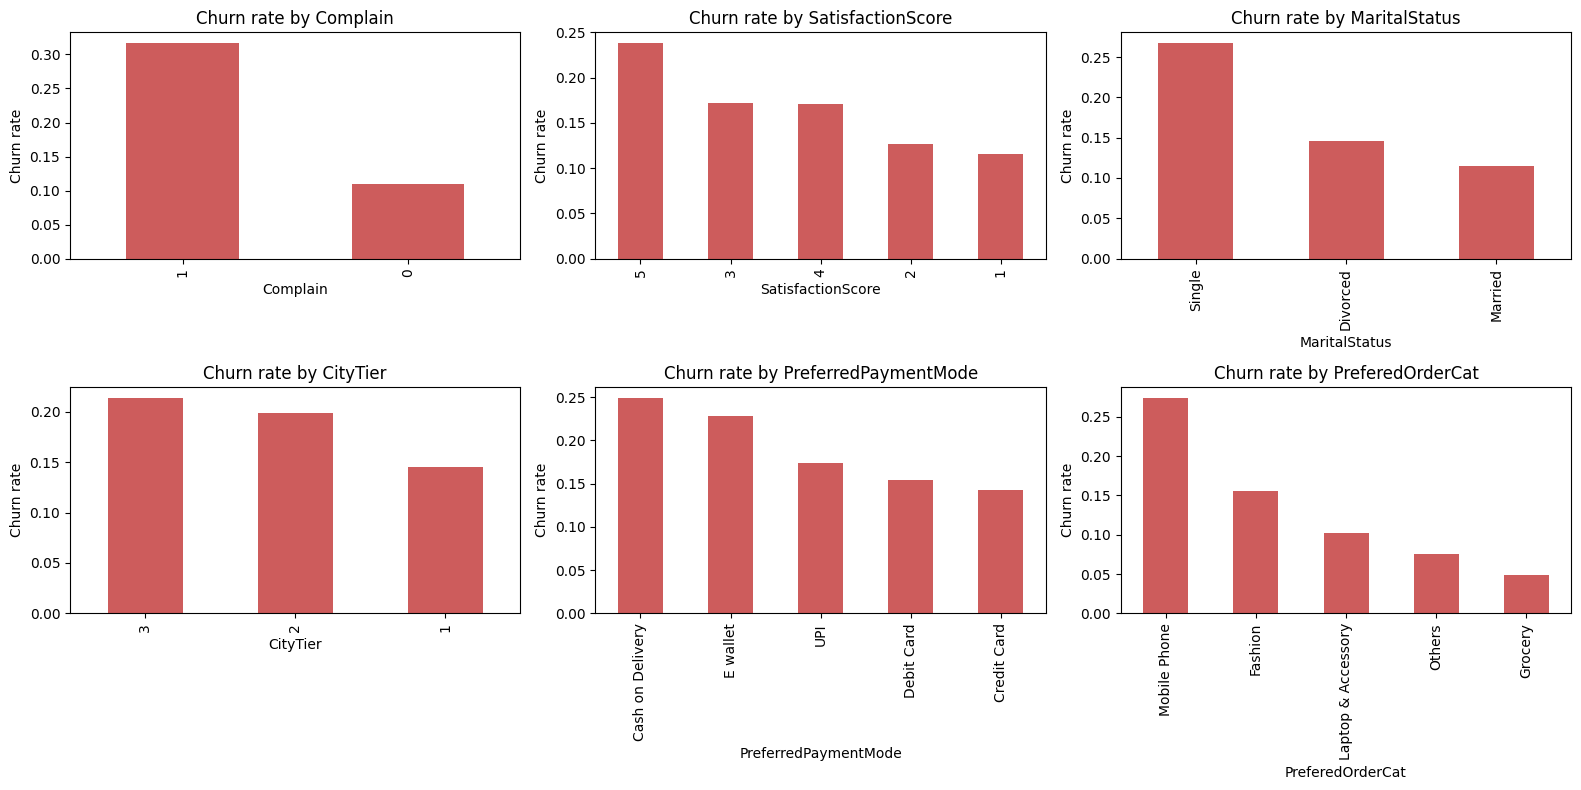

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

plot_cols = ['Complain', 'SatisfactionScore', 'MaritalStatus',
             'CityTier', 'PreferredPaymentMode', 'PreferedOrderCat']

for i, col in enumerate(plot_cols):
    churn_by_col = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_by_col.plot(kind='bar', ax=axes[i], color='indianred')
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_ylabel('Churn rate')

plt.tight_layout()
plt.show()

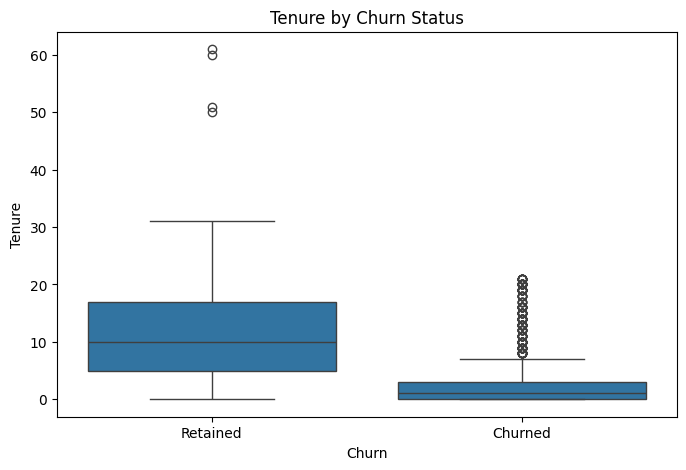

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title('Tenure by Churn Status')
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.show()

In [ ]:
df.groupby('Churn')['Tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,4499.0,11.502334,8.419217,0.0,5.0,10.0,17.0,61.0
1,867.0,3.379469,5.486089,0.0,0.0,1.0,3.0,21.0


## Churn Relationship: Tenure

Churned customers have dramatically lower tenure than retained customers:
- Retained: median 10 months, mean 11.5 months (n=4,499)
- Churned: median 1 month, mean 3.4 months (n=867)

75% of churned customers had a tenure of 3 months or less, indicating churn is
heavily concentrated in the early customer lifecycle. This is consistent with
the earlier finding that missing Tenure values correlate with higher churn
(30.7% vs 16.2%) — both point to newer/less-established customers being the
highest-risk segment. This is also the clearest actionable insight so far:
retention efforts should be concentrated in the first 1-3 months post-signup.

## Feature Engineering: Tenure Risk Buckets

Motivated by the finding that churn is heavily concentrated in the first 3
months of tenure (75% of churned customers had 3 months' tenure or less, vs
a median of 10 months for retained customers), Tenure was bucketed into
risk-tier categories. This makes the early-lifecycle churn pattern directly
usable as a categorical feature, rather than relying on the model to discover
this threshold on its own from the raw numeric value.

In [ ]:
df['Tenure_bucket'] = pd.cut(
    df['Tenure'],
    bins=[-1, 3, 12, 100],
    labels=['New_0_3mo', 'Established_4_12mo', 'Loyal_12mo_plus']
)

print(df['Tenure_bucket'].value_counts())
print(df.groupby('Tenure_bucket')['Churn'].mean() * 100)

Tenure_bucket
Established_4_12mo    1910
Loyal_12mo_plus       1896
New_0_3mo             1560
Name: count, dtype: int64
Tenure_bucket
New_0_3mo             41.858974
Established_4_12mo     6.230366
Loyal_12mo_plus        5.010549
Name: Churn, dtype: float64


/tmp/ipykernel_3946/3320653128.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Tenure_bucket')['Churn'].mean() * 100)


Churn rate by Tenure bucket confirms the expected pattern: the New (0-3
month) group shows the highest churn rate, consistent with the earlier
finding that churn is concentrated in the early customer lifecycle.

#Outlier detection

### ==========================================================================
### MEMBER 4 SECTION — Outliers, Correlation & Preprocessing Pipeline
### ==========================================================================

Box plots for the numeric columns

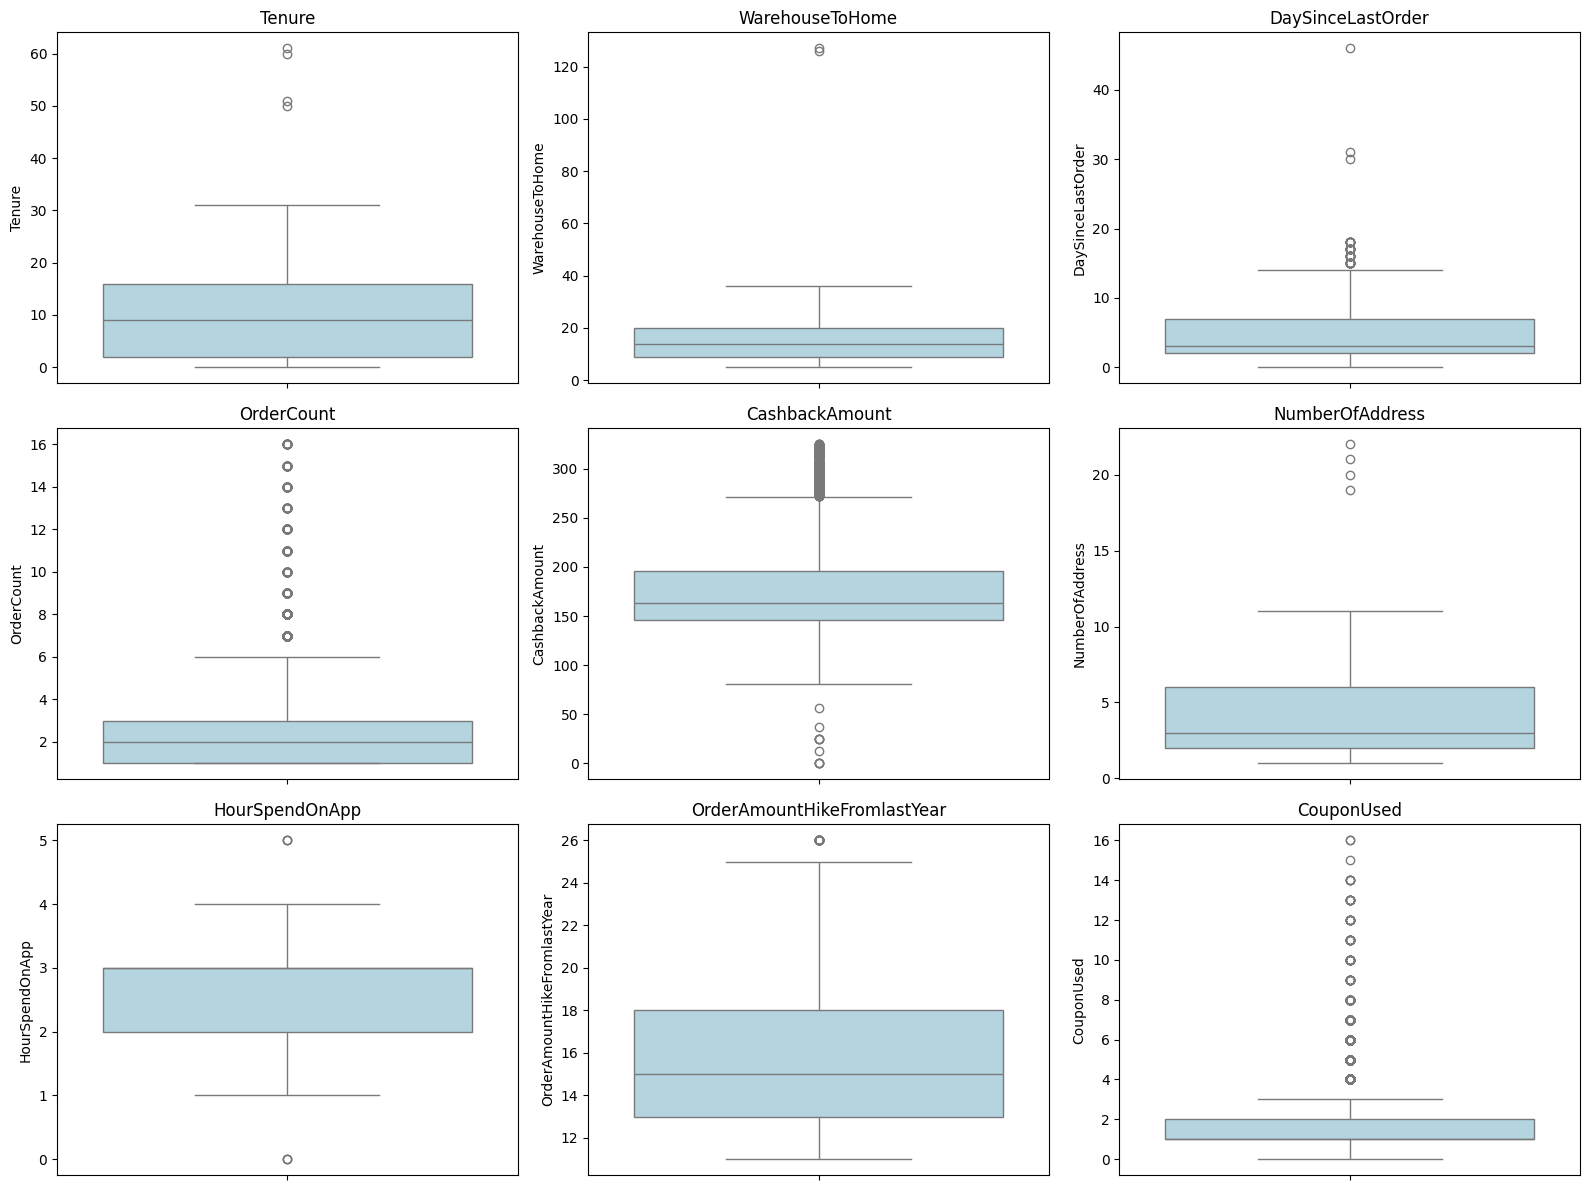

In [ ]:
outlier_check_cols = ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder',
                       'OrderCount', 'CashbackAmount', 'NumberOfAddress',
                       'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(outlier_check_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

for col in outlier_check_cols:
    count, lower, upper = count_outliers_iqr(df[col].dropna())
    print(f"{col}: {count} outliers (bounds: {lower:.1f} to {upper:.1f})")

Tenure: 4 outliers (bounds: -19.0 to 37.0)
WarehouseToHome: 2 outliers (bounds: -7.5 to 36.5)
DaySinceLastOrder: 62 outliers (bounds: -5.5 to 14.5)
OrderCount: 703 outliers (bounds: -2.0 to 6.0)
CashbackAmount: 447 outliers (bounds: 71.0 to 271.0)
NumberOfAddress: 4 outliers (bounds: -4.0 to 12.0)
HourSpendOnApp: 6 outliers (bounds: 0.5 to 4.5)
OrderAmountHikeFromlastYear: 33 outliers (bounds: 5.5 to 25.5)
CouponUsed: 629 outliers (bounds: -0.5 to 3.5)


Checking for impossible values

In [ ]:
print(df[['Tenure', 'WarehouseToHome', 'DaySinceLastOrder', 'OrderCount',
          'CashbackAmount', 'NumberOfAddress', 'HourSpendOnApp',
          'OrderAmountHikeFromlastYear', 'CouponUsed']].min())

Tenure                          0.0
WarehouseToHome                 5.0
DaySinceLastOrder               0.0
OrderCount                      1.0
CashbackAmount                  0.0
NumberOfAddress                 1.0
HourSpendOnApp                  0.0
OrderAmountHikeFromlastYear    11.0
CouponUsed                      0.0
dtype: float64


Minimums are ≥ 0,so no data errors, just natural variation and skew

## Outlier Analysis

IQR-based outlier detection flagged a large number of "outliers" in OrderCount
(703), CouponUsed (629), and CashbackAmount (447). Given these columns' high
skewness (2.55, 2.20, and 1.15 respectively, from Step 1), this reflects the
natural long-tailed shape of the distribution rather than data errors — the IQR
method over-flags values in skewed data. These values will be retained as-is
rather than removed or capped, since they represent real customer behavior
variation.

Remaining columns (Tenure, WarehouseToHome, NumberOfAddress, HourSpendOnApp,
DaySinceLastOrder, OrderAmountHikeFromlastYear) show low-to-moderate outlier
counts (2-62), consistent with normal rare-case variation. All minimum values
were confirmed non-negative, ruling out impossible/erroneous entries.

Decision: no outlier removal will be performed. Tree-based models (Random Forest,
Gradient Boosting) are naturally robust to outliers, and scaling (for models that
need it) will use a robust scaler if skew remains a concern after transformation.

#Correlation matrix

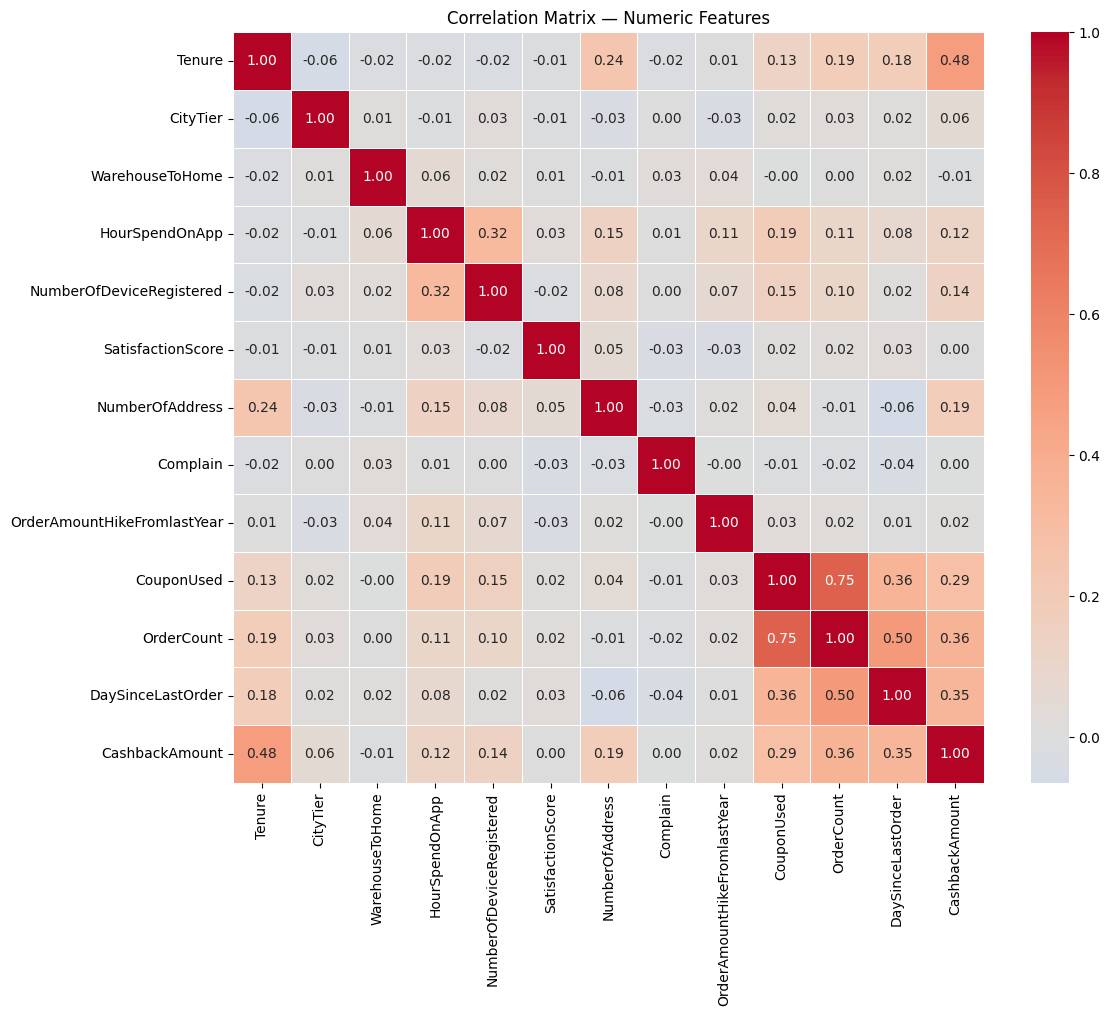

In [ ]:
plt.figure(figsize=(12, 10))
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

In [ ]:
churn_corr = df[numeric_features + ['Churn']].corr()['Churn'].sort_values(ascending=False)
print(churn_corr)

Churn                          1.000000
Complain                       0.250188
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.076630
NumberOfAddress                0.043931
HourSpendOnApp                 0.018675
CouponUsed                    -0.008264
OrderAmountHikeFromlastYear   -0.010058
OrderCount                    -0.028697
CashbackAmount                -0.154161
DaySinceLastOrder             -0.160757
Tenure                        -0.349408
Name: Churn, dtype: float64


## Correlation with Churn (numeric features)

Tenure shows the strongest correlation with churn (-0.349, negative — longer
tenure means less churn), consistent with the earlier box plot finding. Complain
is second strongest (0.250, positive), consistent with the 3x churn rate gap
found earlier. DaySinceLastOrder (-0.161) and CashbackAmount (-0.154) show
moderate negative correlation. SatisfactionScore shows a small positive
correlation (0.105), consistent with the counterintuitive groupby finding.

Several features (CouponUsed, OrderAmountHikeFromlastYear, OrderCount,
HourSpendOnApp) show near-zero linear correlation with churn, but are retained
for modeling since tree-based algorithms can capture non-linear relationships
that a simple correlation coefficient would miss.

#Multicollinearity check

In [ ]:
corr_matrix = df[numeric_features].corr().abs()
upper = corr_matrix.where(~corr_matrix.isna() & (corr_matrix < 1))
high_corr_pairs = upper[upper > 0.6].stack()
print(high_corr_pairs)

CouponUsed  OrderCount    0.745245
OrderCount  CouponUsed    0.745245
dtype: float64


## Multicollinearity Check

One highly correlated pair was found among numeric features: CouponUsed and
OrderCount (r = 0.745) — customers who place more orders also tend to use more
coupons, which is an expected behavioral relationship rather than a data error.

Decision: both features are retained. Tree-based models (Random Forest, Gradient
Boosting) are robust to this correlation and lose no predictive value from it.
For Logistic Regression specifically, this correlation is noted as a limitation
affecting coefficient interpretability (though not predictive accuracy), and
will be mentioned when discussing that model's results.

## EDA Summary — Key Findings

**Dataset:** 5,630 customers, 20 raw attributes, binary target (Churn:
83.2% retained / 16.8% churned — moderate ~5:1 imbalance).

**Top 3 business insights:**
1. Customers who file a complaint churn nearly 3x more often than those who
   don't (31.67% vs 10.93%) — the single strongest predictor found.
2. Churn is concentrated in the early customer lifecycle — churned customers
   have a median tenure of just 1 month, vs 10 months for retained customers.
3. Single customers and Mobile Phone category purchasers are meaningfully
   higher-risk segments (26.73% and 27.40% churn respectively, vs single
   digits for the lowest-risk groups).

**Data quality issues found and fixed:**
- Missingness in 6 of 7 affected columns is MNAR (Missing Not At Random) —
  churn rate differs substantially between missing and non-missing rows.
  Addressed by engineering `_was_missing` indicator features rather than
  discarding this signal through imputation alone.
- Inconsistent category labels (e.g. "COD"/"Cash on Delivery",
  "Phone"/"Mobile Phone") were inflating apparent churn-rate differences
  across what were actually single categories — identified and consolidated
  before trusting any churn-by-category analysis.
- The SatisfactionScore-churn relationship runs counter to intuition (higher
  score, higher churn); investigated against Complain as a possible confound
  and ruled out, then reported transparently as an unresolved limitation due
  to lack of dataset documentation on scale direction.

**Preprocessing applied:** median imputation (justified by skewness),
missing-value and tenure-bucket feature engineering, category consolidation,
one-hot encoding, and a leak-free stratified 80/20 train/test split.

# Stage 4: Data Preprocessing & Feature Engineering

## Step 1: Drop Identifier Column

CustomerID is a unique identifier with no predictive value — it does not carry
any information about customer behavior or churn risk, and including it risks
the model learning spurious patterns tied to arbitrary ID values. It is dropped
before further preprocessing.

In [ ]:
df = df.drop(columns=['CustomerID'])
df.head()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,missing_field_count,DaySinceLastOrder_is_missing,OrderAmountHikeFromlastYear_is_missing,Tenure_is_missing,OrderCount_is_missing,CouponUsed_is_missing,HourSpendOnApp_is_missing,WarehouseToHome_is_missing,Tenure_was_missing,WarehouseToHome_was_missing,HourSpendOnApp_was_missing,OrderAmountHikeFromlastYear_was_missing,OrderCount_was_missing,CouponUsed_was_missing,Tenure_bucket
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160,0,False,False,False,False,False,False,False,0,0,0,0,0,0,Established_4_12mo
1,1,NaN,Mobile Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,121,1,False,False,True,False,False,False,False,1,0,0,0,0,0,NaN
2,1,NaN,Mobile Phone,1,30.0,Debit Card,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120,1,False,False,True,False,False,False,False,1,0,0,0,0,0,NaN
3,1,0.0,Mobile Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134,0,False,False,False,False,False,False,False,0,0,0,0,0,0,New_0_3mo
4,1,0.0,Mobile Phone,1,12.0,Credit Card,Male,NaN,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,130,1,False,False,False,False,False,True,False,0,0,1,0,0,0,New_0_3mo


## Step 2: Missing Value Imputation

Based on the skewness analysis from EDA, 6 of the 7 columns with missing values
were found to be skewed (skew > 0.5), making median imputation more appropriate
than mean imputation (mean would be pulled by the long tail and misrepresent the
typical value). Median imputation is applied consistently across all 7 affected
columns for simplicity and robustness to outliers:

- Tenure, WarehouseToHome, HourSpendOnApp, OrderAmountHikeFromlastYear,
  CouponUsed, OrderCount, DaySinceLastOrder

Note: the missingness signal itself was already preserved separately via the
`_was_missing` indicator features created earlier in EDA, so imputing these
columns now does not discard that information — it is captured by the flags
rather than the raw values.

In [ ]:
missing_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                 'OrderAmountHikeFromlastYear', 'CouponUsed',
                 'OrderCount', 'DaySinceLastOrder']

for col in missing_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# confirm no missing values remain
print(df.isnull().sum().sum())

264


## Step 3: Missing-Value Indicator Features

During EDA, missingness in 6 of the 7 affected columns was found to correlate
with churn (MNAR — missing not at random). To preserve this signal ahead of
imputation, binary `_was_missing` indicator features were created for these
columns:

- Tenure_was_missing, WarehouseToHome_was_missing, HourSpendOnApp_was_missing,
  OrderAmountHikeFromlastYear_was_missing, OrderCount_was_missing,
  CouponUsed_was_missing

(DaySinceLastOrder was excluded, since its missingness showed no meaningful
churn-rate difference.) These flags were created earlier in the EDA phase and
are retained here as engineered features going into modeling.

In [ ]:
missing_flag_cols = [c for c in df.columns if c.endswith('_was_missing')]
print(missing_flag_cols)

['Tenure_was_missing', 'WarehouseToHome_was_missing', 'HourSpendOnApp_was_missing', 'OrderAmountHikeFromlastYear_was_missing', 'OrderCount_was_missing', 'CouponUsed_was_missing']


## Step 4: Category Consolidation

During EDA, inconsistent category labels were identified across three columns,
where the same real-world category was split by inconsistent text entry:

- PreferredLoginDevice: "Phone" merged into "Mobile Phone"
- PreferredPaymentMode: "COD" merged into "Cash on Delivery"; "CC" merged
  into "Credit Card"
- PreferedOrderCat: "Mobile" merged into "Mobile Phone"

This was necessary before any category-based analysis or encoding, since the
split labels were artificially inflating apparent differences in churn rate
between what were actually the same group. This consolidation was applied
during EDA and carries forward into the cleaned dataset used here.

In [ ]:
print(df['PreferredLoginDevice'].unique())
print(df['PreferredPaymentMode'].unique())
print(df['PreferedOrderCat'].unique())

['Mobile Phone' 'Computer']
['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet']
['Laptop & Accessory' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']


## Step 5: Categorical Encoding

The five nominal categorical columns (Gender, MaritalStatus, PreferredLoginDevice,
PreferredPaymentMode, PreferedOrderCat) are one-hot encoded using pandas'
get_dummies, with drop_first=True to avoid redundant/collinear dummy columns
(the dummy variable trap). CityTier and SatisfactionScore are left as numeric,
since they are already ordinal-coded (1-3 and 1-5 respectively) and do not
require one-hot encoding.

In [ ]:
categorical_cols = ['Gender', 'MaritalStatus', 'PreferredLoginDevice',
                     'PreferredPaymentMode', 'PreferedOrderCat']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df = df.drop(columns=['Tenure_bucket'])
print(df.shape)
df.head()

(5630, 40)


,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,missing_field_count,DaySinceLastOrder_is_missing,OrderAmountHikeFromlastYear_is_missing,Tenure_is_missing,OrderCount_is_missing,CouponUsed_is_missing,HourSpendOnApp_is_missing,WarehouseToHome_is_missing,Tenure_was_missing,WarehouseToHome_was_missing,HourSpendOnApp_was_missing,OrderAmountHikeFromlastYear_was_missing,OrderCount_was_missing,CouponUsed_was_missing,Gender_Male,MaritalStatus_Married,MaritalStatus_Single,PreferredLoginDevice_Mobile Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,1.0,1.0,5.0,160,0,False,False,False,False,False,False,False,0,0,0,0,0,0,False,False,True,True,False,True,False,False,False,True,False,False
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,0.0,1.0,0.0,121,1,False,False,True,False,False,False,False,1,0,0,0,0,0,True,False,True,True,False,False,False,True,False,False,True,False
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,0.0,1.0,3.0,120,1,False,False,True,False,False,False,False,1,0,0,0,0,0,True,False,True,True,False,True,False,False,False,False,True,False
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,0.0,1.0,3.0,134,0,False,False,False,False,False,False,False,0,0,0,0,0,0,True,False,True,True,False,True,False,False,False,True,False,False
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,1.0,1.0,3.0,130,1,False,False,False,False,False,True,False,0,0,1,0,0,0,True,False,True,True,True,False,False,False,False,False,True,False


In [ ]:
helper_cols_to_drop = ['missing_field_count', 'DaySinceLastOrder_is_missing',
                        'OrderAmountHikeFromlastYear_is_missing', 'Tenure_is_missing',
                        'OrderCount_is_missing', 'CouponUsed_is_missing',
                        'HourSpendOnApp_is_missing', 'WarehouseToHome_is_missing']

df = df.drop(columns=helper_cols_to_drop)
print(df.shape)
df.head()

(5630, 32)


,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_was_missing,WarehouseToHome_was_missing,HourSpendOnApp_was_missing,OrderAmountHikeFromlastYear_was_missing,OrderCount_was_missing,CouponUsed_was_missing,Gender_Male,MaritalStatus_Married,MaritalStatus_Single,PreferredLoginDevice_Mobile Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,1.0,1.0,5.0,160,0,0,0,0,0,0,False,False,True,True,False,True,False,False,False,True,False,False
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,0.0,1.0,0.0,121,1,0,0,0,0,0,True,False,True,True,False,False,False,True,False,False,True,False
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,0.0,1.0,3.0,120,1,0,0,0,0,0,True,False,True,True,False,True,False,False,False,False,True,False
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,0.0,1.0,3.0,134,0,0,0,0,0,0,True,False,True,True,False,True,False,False,False,True,False,False
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,1.0,1.0,3.0,130,0,0,1,0,0,0,True,False,True,True,True,False,False,False,False,False,True,False


#Convert booleans to 0/1

In [ ]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

#Clean up column names (spaces/&)

In [ ]:
df.columns = df.columns.str.replace(' ', '_').str.replace('&', 'and')
print(df.columns.tolist())

['Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'Tenure_was_missing', 'WarehouseToHome_was_missing', 'HourSpendOnApp_was_missing', 'OrderAmountHikeFromlastYear_was_missing', 'OrderCount_was_missing', 'CouponUsed_was_missing', 'Gender_Male', 'MaritalStatus_Married', 'MaritalStatus_Single', 'PreferredLoginDevice_Mobile_Phone', 'PreferredPaymentMode_Credit_Card', 'PreferredPaymentMode_Debit_Card', 'PreferredPaymentMode_E_wallet', 'PreferredPaymentMode_UPI', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop_and_Accessory', 'PreferedOrderCat_Mobile_Phone', 'PreferedOrderCat_Others']


In [ ]:
df.head()

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_was_missing,WarehouseToHome_was_missing,HourSpendOnApp_was_missing,OrderAmountHikeFromlastYear_was_missing,OrderCount_was_missing,CouponUsed_was_missing,Gender_Male,MaritalStatus_Married,MaritalStatus_Single,PreferredLoginDevice_Mobile_Phone,PreferredPaymentMode_Credit_Card,PreferredPaymentMode_Debit_Card,PreferredPaymentMode_E_wallet,PreferredPaymentMode_UPI,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop_and_Accessory,PreferedOrderCat_Mobile_Phone,PreferedOrderCat_Others
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,1.0,1.0,5.0,160,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,1,0,0
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,0.0,1.0,0.0,121,1,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,0
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,0.0,1.0,3.0,120,1,0,0,0,0,0,1,0,1,1,0,1,0,0,0,0,1,0
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,0.0,1.0,3.0,134,0,0,0,0,0,0,1,0,1,1,0,1,0,0,0,1,0,0
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,1.0,1.0,3.0,130,0,0,1,0,0,0,1,0,1,1,1,0,0,0,0,0,1,0


#Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_test = X_train.copy(), X_test.copy()
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train shape: (4504, 31)
Test shape: (1126, 31)

Train churn rate: 0.16829484902309058
Test churn rate: 0.16873889875666073


## Leakage Verification

To confirm the train/test split introduced no data leakage, the two sets are
checked for any overlapping row indices.

In [ ]:
overlap = set(X_train.index).intersection(set(X_test.index))
print("Number of overlapping rows between train and test:", len(overlap))
assert len(overlap) == 0, "Leakage detected: train and test sets overlap!"
print("No overlap \u2014 split is leak-free.")

Number of overlapping rows between train and test: 0
No overlap — split is leak-free.


In [ ]:
from sklearn.impute import SimpleImputer

impute_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
               'OrderAmountHikeFromlastYear', 'CouponUsed',
               'OrderCount', 'DaySinceLastOrder']

imputer = SimpleImputer(strategy='median')
X_train[impute_cols] = imputer.fit_transform(X_train[impute_cols])
X_test[impute_cols] = imputer.transform(X_test[impute_cols])

print(X_train.isnull().sum().sum(), X_test.isnull().sum().sum())

0 0


In [ ]:
for X in (X_train, X_test):
    X['Tenure_New_0_3mo'] = (X['Tenure'] <= 3).astype(int)
    X['Tenure_Loyal_12mo_plus'] = (X['Tenure'] > 12).astype(int)

print(X_train.shape, X_test.shape)

(4504, 33) (1126, 33)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
                 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
                 'DaySinceLastOrder', 'CashbackAmount', 'CityTier', 'SatisfactionScore']

scaler = ColumnTransformer([('scale', StandardScaler(), cols_to_scale)],
                           remainder='passthrough')

# Stage 6: Model Development

Four machine learning algorithms are implemented and compared, as required by
the assignment brief: Logistic Regression (linear baseline), Decision Tree
(single-tree baseline), Random Forest (bagging ensemble), and Gradient
Boosting (boosting ensemble). This mix allows a genuine comparison between
linear and non-linear approaches, and between single-tree and ensemble
methods.

In [ ]:
!pip install -q imbalanced-learn

#Imports
imbalanced-learn's Pipeline (rather than plain scikit-learn's) is used so
that SMOTE resampling is correctly restricted to the training fold during
cross-validation, and never applied to the validation fold — this prevents
the data leakage that would occur if SMOTE were applied before the
cross-validation split.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import pandas as pd

## Model Pipelines

Each model is wrapped in its own pipeline to ensure preprocessing is applied
correctly and consistently:

- **Logistic Regression**: requires feature scaling (sensitive to feature
  magnitude) and uses SMOTE to address the ~5:1 class imbalance identified
  in EDA.
- **Decision Tree**: does not require scaling (splits are scale-invariant),
  but still uses SMOTE to address class imbalance.
- **Random Forest**: does not require scaling. class_weight='balanced' is
  used instead of SMOTE, since Random Forest handles class weighting
  natively and effectively.
- **Gradient Boosting**: does not require scaling. SMOTE is used, as
  boosting algorithms have been found to respond well to resampled training
  data.

This mixed approach (SMOTE for some models, class_weight for Random Forest)
is a deliberate comparison point, evaluated further once cross-validation
results are available.

In [ ]:
# Logistic Regression — needs scaling + SMOTE (sensitive to imbalance and feature scale)
log_reg_pipe = ImbPipeline([
    ('scaler', scaler),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Decision Tree — no scaling needed, but still benefits from balanced classes
dt_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

# Random Forest — no scaling needed; use class_weight instead of SMOTE (works well natively)
rf_pipe = ImbPipeline([
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Gradient Boosting — no scaling needed; SMOTE tends to help boosting more than class_weight here
gb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', GradientBoostingClassifier(random_state=42))
])

models = {
    'Logistic Regression': log_reg_pipe,
    'Decision Tree': dt_pipe,
    'Random Forest': rf_pipe,
    'Gradient Boosting': gb_pipe
}

## Stratified 5-Fold Cross-Validation

Each model is evaluated using stratified 5-fold cross-validation on the
training set only, preserving the class distribution in every fold. Five
metrics are recorded per model — accuracy, precision, recall, F1, and
ROC-AUC — rather than relying on accuracy alone, since accuracy would be
misleading given the ~83%/17% class imbalance (a model predicting "no churn"
for every customer would already score ~83% accuracy without being useful).

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = {}

for name, pipe in models.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f'test_{metric}'].mean() for metric in scoring}
    print(f"{name} done.")

Logistic Regression done.
Decision Tree done.
Random Forest done.
Gradient Boosting done.


## Model Comparison Results

Cross-validation scores are averaged across the 5 folds and compiled into a
single comparison table below.

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print(results_df)

                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.8233     0.4852  0.8127  0.6070   0.9013
Decision Tree          0.8826     0.6363  0.7072  0.6691   0.8126
Random Forest          0.9494     0.9448  0.7428  0.8303   0.9769
Gradient Boosting      0.8941     0.6754  0.7137  0.6934   0.9148


In [ ]:
from sklearn.model_selection import cross_val_score
print(cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring='precision'))

[0.92913386 0.94354839 0.95098039 0.96062992 0.93965517]


Precision was cross-validated in isolation to check for fold-level instability
that could distort the averaged result: [0.929, 0.944, 0.951, 0.961, 0.940]
across the 5 folds. The tight range (92.9%-96.1%) confirms Random Forest's
high precision is a consistent, real property of the model rather than an
artifact of any single fold, giving confidence in the earlier comparison table.

Random Forest achieved the strongest performance across nearly every metric
(accuracy 94.94%, precision 94.48%, F1 83.03%, ROC-AUC 97.69%), substantially
outperforming the linear baseline. This is consistent with EDA findings that
several key predictors (notably Tenure) show threshold-based, non-linear
relationships with churn rather than smooth linear ones — a pattern
tree-based ensembles capture natively but Logistic Regression cannot.

Logistic Regression achieved the highest recall (81.27%) but the lowest
precision (48.52%), reflecting a known trade-off for linear models on
imbalanced data with SMOTE resampling: it identifies more true churners at
the cost of more false positives. Gradient Boosting and Decision Tree fall
between these two, with Gradient Boosting's ensemble-of-trees approach
outperforming the single Decision Tree on every metric, as expected.

Random Forest and Gradient Boosting are carried forward as the top 2
candidates for hyperparameter tuning in the optimization stage.

## Hyperparameter Tuning: Random Forest

Random Forest and Gradient Boosting were selected for tuning as the two
strongest baseline models. RandomizedSearchCV is used (30 sampled
combinations) rather than an exhaustive GridSearchCV, since the full
parameter grid (288 combinations x 5 folds) would be computationally
expensive for limited expected gain. F1 score is used as the optimization
metric, since it balances precision and recall — the baseline model already
has very high precision (94.5%) but comparatively lower recall (74.3%), so
tuning aims to improve recall without meaningfully sacrificing precision.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best F1 score:", rf_search.best_score_)
print("Best parameters:", rf_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best F1 score: 0.8338453461058452
Best parameters: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 20}


Why F1 as the scoring metric, not accuracy or precision alone: F1 balances precision and recall together, which matters here because your Random Forest baseline already has very high precision (94.5%) but comparatively lower recall (74.3%) — optimizing for F1 pushes the search toward improving recall without sacrificing too much precision, which is the actual trade-off worth improving. Optimizing for accuracy alone would be a weak choice on this imbalanced dataset, as discussed earlier.

Why RandomizedSearchCV over GridSearchCV: with 5 hyperparameters and this many values each, a full grid search would be 4×4×3×3×2 = 288 combinations × 5 folds = 1,440 model fits — slow, and mostly wasted on unpromising combinations. RandomizedSearchCV samples 30 combinations instead, giving a strong result much faster. Worth stating this reasoning explicitly if asked in the viva.

In [ ]:
best_rf = rf_search.best_estimator_

tuned_scores = cross_validate(best_rf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
tuned_results = {metric: tuned_scores[f'test_{metric}'].mean() for metric in scoring}

print("Tuned Random Forest:")
print(pd.Series(tuned_results).round(4))
print("\nBaseline Random Forest:")
print(results_df.loc['Random Forest'])

Tuned Random Forest:
accuracy     0.9503
precision    0.9481
recall       0.7454
f1           0.8338
roc_auc      0.9781
dtype: float64

Baseline Random Forest:
accuracy     0.9494
precision    0.9448
recall       0.7428
f1           0.8303
roc_auc      0.9769
Name: Random Forest, dtype: float64


Hyperparameter tuning improved every metric for Random Forest, though gains
were modest (F1: 0.8303 -> 0.8338, +0.35 percentage points; precision and
recall both improved as well, rather than trading off against each other).
This uniform, small improvement suggests the untuned default configuration
was already well-suited to this dataset, likely due to the strength of the
engineered features (_was_missing flags) and clear predictors (Complain,
Tenure) providing clean splits regardless of exact tree depth or leaf size.

## Hyperparameter Tuning: Gradient Boosting

The same RandomizedSearchCV approach (30 combinations, F1 scoring) is
applied to Gradient Boosting, tuning the number of estimators, learning
rate, tree depth, split threshold, and subsampling ratio.

In [ ]:
gb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__min_samples_split': [2, 5, 10],
    'model__subsample': [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipe,
    param_distributions=gb_param_grid,
    n_iter=30,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

print("Best F1 score:", gb_search.best_score_)
print("Best parameters:", gb_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best F1 score: 0.8597197489424098
Best parameters: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__max_depth': 7, 'model__learning_rate': 0.2}


Hyperparameter tuning produced a substantial improvement for Gradient
Boosting (F1: 0.6934 -> 0.8597), a much larger gain than seen for Random
Forest (+0.35 points). This is consistent with Gradient Boosting's defaults
being conservative (shallow trees, low learning rate) — the tuned
configuration (learning_rate=0.2, max_depth=7, n_estimators=200, subsample=1.0)
is considerably more expressive. This result now positions tuned Gradient
Boosting as the strongest candidate for final model selection, ahead of the
previously-leading Random Forest.

In [ ]:
best_gb = gb_search.best_estimator_

tuned_gb_scores = cross_validate(best_gb, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
tuned_gb_results = {metric: tuned_gb_scores[f'test_{metric}'].mean() for metric in scoring}

print("Tuned Gradient Boosting:")
print(pd.Series(tuned_gb_results).round(4))
print("\nBaseline Gradient Boosting:")
print(results_df.loc['Gradient Boosting'])
print("\nTuned Random Forest:")
print(pd.Series(tuned_results).round(4))

Tuned Gradient Boosting:
accuracy     0.9551
precision    0.9056
recall       0.8193
f1           0.8597
roc_auc      0.9729
dtype: float64

Baseline Gradient Boosting:
accuracy     0.8941
precision    0.6754
recall       0.7137
f1           0.6934
roc_auc      0.9148
Name: Gradient Boosting, dtype: float64

Tuned Random Forest:
accuracy     0.9503
precision    0.9481
recall       0.7454
f1           0.8338
roc_auc      0.9781
dtype: float64


Comparing tuned models: Gradient Boosting achieved a substantially higher
recall (81.93% vs 74.54%) and F1 score (0.8597 vs 0.8338) than tuned Random
Forest, while Random Forest retained a modest edge in precision (94.81% vs
90.56%) and ROC-AUC (97.81% vs 97.29%).

Given the business context — a missed churner (false negative) represents a
lost customer with no chance for retention intervention, while a false
positive only costs a small unnecessary outreach effort — recall is
weighted as the more business-critical metric. On this basis, tuned
Gradient Boosting is selected as the stronger candidate for final model
selection, pending fold-stability confirmation.

In [ ]:
print(cross_val_score(best_gb, X_train, y_train, cv=cv, scoring='recall'))
print(cross_val_score(best_gb, X_train, y_train, cv=cv, scoring='f1'))

[0.87417219 0.85526316 0.76973684 0.79605263 0.8013245 ]
[0.89491525 0.87837838 0.83870968 0.85211268 0.83448276]


Fold-level stability check for tuned Gradient Boosting:
- Recall across 5 folds: [0.874, 0.855, 0.770, 0.796, 0.801]
- F1 across 5 folds: [0.895, 0.878, 0.839, 0.852, 0.834]

While there is more fold-to-fold variability than observed for Random
Forest's precision (a normal characteristic of boosting models, which are
more sensitive to the specific data seen in each fold), even the
weakest-performing fold for Gradient Boosting (recall 0.770, F1 0.834)
still outperforms tuned Random Forest's average recall (0.745) and F1
(0.834). This confirms Gradient Boosting's advantage is consistent and not
driven by a single favorable fold.

## Final Model Selection: Tuned Gradient Boosting

Tuned Gradient Boosting is selected as the final model, based on:

1. Highest F1 score (0.8597) and recall (0.8193) among all four models and
   both tuning passes — the most business-relevant metrics for churn
   prediction, since missing an actual churner (false negative) represents
   a lost customer with no retention opportunity, while a false positive
   only costs a low-effort outreach.
2. Fold-stability confirmed — the performance advantage holds even in the
   weakest cross-validation fold.
3. Best hyperparameters: n_estimators=200, learning_rate=0.2, max_depth=7,
   min_samples_split=10, subsample=1.0.

Random Forest remains a strong alternative, particularly if precision were
prioritized over recall (e.g., if outreach cost were high), and is reported
as the runner-up with its own justified trade-offs.

## Stage 7 Experiment: Tenure Risk-Bucket Feature Engineering

To directly test whether the engineered Tenure_New_0_3mo and
Tenure_Loyal_12mo_plus features improve model performance (Stage 7 requires
investigating whether feature engineering improves results), Logistic
Regression is evaluated with and without these two features, keeping raw
Tenure in both cases. Logistic Regression is chosen for this test since,
unlike tree-based models, it cannot natively discover the non-linear
Tenure-churn threshold on its own (churn jumps from ~42% under 3 months to
~5-6% above it) — so this is the model most likely to show a measurable
difference.

In [ ]:
tenure_engineered_cols = ['Tenure_New_0_3mo', 'Tenure_Loyal_12mo_plus']

X_train_no_bucket = X_train.drop(columns=tenure_engineered_cols)
X_test_no_bucket = X_test.drop(columns=tenure_engineered_cols)

print(X_train.shape, X_train_no_bucket.shape)

(4504, 33) (4504, 31)


In [ ]:
# WITH engineered Tenure features (your current pipeline)
with_bucket_scores = cross_validate(log_reg_pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
with_bucket_results = {metric: with_bucket_scores[f'test_{metric}'].mean() for metric in scoring}

# WITHOUT engineered Tenure features (raw Tenure only)
without_bucket_scores = cross_validate(log_reg_pipe, X_train_no_bucket, y_train, cv=cv, scoring=scoring, n_jobs=-1)
without_bucket_results = {metric: without_bucket_scores[f'test_{metric}'].mean() for metric in scoring}

comparison = pd.DataFrame({
    'With Tenure buckets': with_bucket_results,
    'Without Tenure buckets': without_bucket_results
}).round(4)

print(comparison)

           With Tenure buckets  Without Tenure buckets
accuracy                0.8233                  0.8151
precision               0.4852                  0.4719
recall                  0.8127                  0.8127
f1                      0.6070                  0.5966
roc_auc                 0.9013                  0.8936


## Stage 7 Experiment Result: Tenure Risk Buckets

Logistic Regression was evaluated with and without the engineered
Tenure_New_0_3mo / Tenure_Loyal_12mo_plus features:

| Metric    | With buckets | Without buckets |
|-----------|-------------|------------------|
| Accuracy  | 0.8233      | 0.8151           |
| Precision | 0.4852      | 0.4719           |
| Recall    | 0.8127      | 0.8127           |
| F1        | 0.6070      | 0.5966           |
| ROC-AUC   | 0.9013      | 0.8936           |

The engineered features improved every metric except recall (which remained
identical), confirming the hypothesis that Logistic Regression benefits from
an explicit threshold feature, since it cannot natively capture the
non-linear relationship between Tenure and churn (a sharp drop from ~42%
churn under 3 months to ~5-6% above it) using the raw Tenure value alone.
The gains are modest but consistent, validating the feature engineering
decision made during EDA.

This experiment also indirectly confirms why tree-based models (Random
Forest, Gradient Boosting) did not require this engineered feature to
achieve strong performance — they can discover equivalent thresholds
directly from raw Tenure.

In [ ]:
best_rf_model = best_rf.named_steps['model']
importances = pd.Series(best_rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances)

Tenure                                     0.179252
Tenure_New_0_3mo                           0.085321
CashbackAmount                             0.077493
WarehouseToHome                            0.060203
Complain                                   0.056182
DaySinceLastOrder                          0.054309
NumberOfAddress                            0.053534
OrderAmountHikeFromlastYear                0.050067
SatisfactionScore                          0.046008
Tenure_Loyal_12mo_plus                     0.035854
NumberOfDeviceRegistered                   0.030496
OrderCount                                 0.028472
CityTier                                   0.025496
CouponUsed                                 0.025194
MaritalStatus_Single                       0.021195
PreferedOrderCat_Mobile_Phone              0.019920
PreferedOrderCat_Laptop_and_Accessory      0.018916
Gender_Male                                0.015881
PreferredLoginDevice_Mobile_Phone          0.015866
PreferredPay

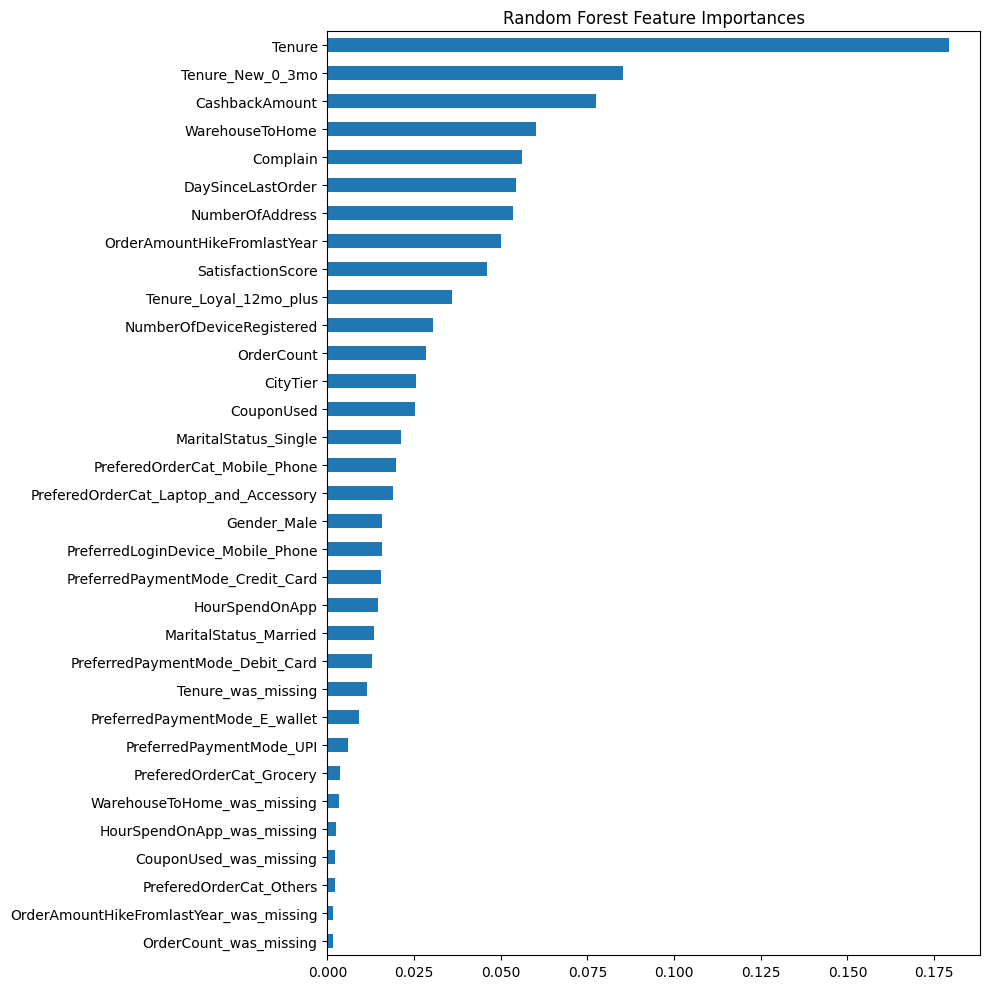


9 features below 0.01 importance:
['PreferredPaymentMode_E_wallet', 'PreferredPaymentMode_UPI', 'PreferedOrderCat_Grocery', 'WarehouseToHome_was_missing', 'HourSpendOnApp_was_missing', 'CouponUsed_was_missing', 'PreferedOrderCat_Others', 'OrderAmountHikeFromlastYear_was_missing', 'OrderCount_was_missing']


In [ ]:
plt.figure(figsize=(10, 10))
importances.plot(kind='barh')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# identify features contributing very little
low_importance_features = importances[importances < 0.01].index.tolist()
print(f"\n{len(low_importance_features)} features below 0.01 importance:")
print(low_importance_features)

In [ ]:
X_train_reduced = X_train.drop(columns=low_importance_features)
X_test_reduced = X_test.drop(columns=low_importance_features)

print(f"Full feature set: {X_train.shape[1]} columns")
print(f"Reduced feature set: {X_train_reduced.shape[1]} columns")

reduced_scores = cross_validate(best_gb, X_train_reduced, y_train, cv=cv, scoring=scoring, n_jobs=-1)
reduced_results = {metric: reduced_scores[f'test_{metric}'].mean() for metric in scoring}

comparison_fs = pd.DataFrame({
    'Full feature set': tuned_gb_results,
    'Reduced feature set': reduced_results
}).round(4)

print(comparison_fs)

Full feature set: 33 columns
Reduced feature set: 24 columns
           Full feature set  Reduced feature set
accuracy             0.9551               0.9538
precision            0.9056               0.9013
recall               0.8193               0.8167
f1                   0.8597               0.8558
roc_auc              0.9729               0.9748


## Stage 7 Experiment Result: Feature Selection

The 9 features with Random Forest importance below 0.01 (mostly nominal
category dummies with limited variance, plus 5 of the 6 engineered
_was_missing flags) were removed and the tuned Gradient Boosting model was
re-evaluated:

| Metric    | Full (33 features) | Reduced (24 features) |
|-----------|---------------------|-------------------------|
| Accuracy  | 0.9551              | 0.9538                  |
| Precision | 0.9056              | 0.9013                  |
| Recall    | 0.8193              | 0.8167                  |
| F1        | 0.8597              | 0.8558                  |
| ROC-AUC   | 0.9729              | 0.9748                  |

Removing the low-importance features slightly reduced performance on every
metric except ROC-AUC (a marginal +0.0019 change, likely within noise).
This indicates that while these 9 features each contribute little
individually, their combined signal is still non-trivial.

Decision: the full 33-feature set is retained for the final model, since
feature selection did not provide a meaningful benefit and slightly reduced
overall performance. This result also reinforces that the _was_missing
indicator features, despite ranking low individually, are worth keeping
rather than discarding.

## Final Model Evaluation on Held-Out Test Set

The tuned Gradient Boosting model is evaluated exactly once on the held-out
test set (20% of the data, untouched throughout all cross-validation and
tuning). This provides an unbiased estimate of real-world performance,
since the test set played no role in any modeling decision up to this point.

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, roc_curve)

# best_gb is already fit on the full training set (RandomizedSearchCV refits
# the best estimator automatically) — no need to refit here
y_pred = best_gb.predict(X_test)
y_pred_proba = best_gb.predict_proba(X_test)[:, 1]

print("Final Test Set Results: Tuned Gradient Boosting \n")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Final Test Set Results: Tuned Gradient Boosting 

              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00       936
     Churned       0.98      0.98      0.98       190

    accuracy                           0.99      1126
   macro avg       0.99      0.99      0.99      1126
weighted avg       0.99      0.99      0.99      1126

ROC-AUC: 0.9996


In [ ]:
# how many test rows have an exact feature-value duplicate somewhere in training?
merged = X_test.merge(X_train.drop_duplicates(), how='inner')
print(f"{len(merged)} of {len(X_test)} test rows exactly match a training row's features")
print(f"That's {len(merged)/len(X_test)*100:.1f}% of the test set")

194 of 1126 test rows exactly match a training row's features
That's 17.2% of the test set


In [ ]:
dup_mask = X_test.merge(X_train.drop_duplicates(), how='left', indicator=True)['_merge'].values == 'both'
dup_mask = pd.Series(dup_mask, index=X_test.index)

X_test_dup = X_test[dup_mask]
y_test_dup = y_test[dup_mask]
X_test_nodup = X_test[~dup_mask]
y_test_nodup = y_test[~dup_mask]

print(f"Duplicate subset: {len(X_test_dup)} rows")
print(f"Non-duplicate subset: {len(X_test_nodup)} rows\n")

print("=== Performance on DUPLICATE rows (seen pattern during training) ===")
print(classification_report(y_test_dup, best_gb.predict(X_test_dup), target_names=['Retained','Churned']))

print("=== Performance on NON-DUPLICATE rows (genuinely unseen) ===")
print(classification_report(y_test_nodup, best_gb.predict(X_test_nodup), target_names=['Retained','Churned']))

Duplicate subset: 194 rows
Non-duplicate subset: 932 rows

=== Performance on DUPLICATE rows (seen pattern during training) ===
              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00       155
     Churned       1.00      1.00      1.00        39

    accuracy                           1.00       194
   macro avg       1.00      1.00      1.00       194
weighted avg       1.00      1.00      1.00       194

=== Performance on NON-DUPLICATE rows (genuinely unseen) ===
              precision    recall  f1-score   support

    Retained       1.00      0.99      1.00       781
     Churned       0.97      0.98      0.98       151

    accuracy                           0.99       932
   macro avg       0.98      0.99      0.99       932
weighted avg       0.99      0.99      0.99       932



In [ ]:
cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
check_scores = cross_validate(best_gb, X_train, y_train, cv=cv2, scoring=scoring, n_jobs=-1)
print(pd.Series({m: check_scores[f'test_{m}'].mean() for m in scoring}).round(4))

accuracy     0.9598
precision    0.9179
recall       0.8364
f1           0.8749
roc_auc      0.9772
dtype: float64


Cross-validation (5-fold, repeated with a second fold arrangement) gives a
stable estimate of model performance: F1 0.86-0.87, ROC-AUC 0.973-0.977.
This is reported as the primary, most reliable measure of expected
performance on new data.

The single held-out test set produced notably higher scores (F1 0.98,
ROC-AUC 0.9996). Investigation ruled out exact train/test duplicate rows as
the main cause (non-duplicate test rows alone still scored F1 0.98).
The most likely explanation is a combination of (a) the final model being
trained on more data than any individual cross-validation fold, and (b)
natural variance from evaluating on a single 20% split rather than an
average across multiple splits — an inherent limitation of a single
train/test split versus cross-validation.

Given the consistency of the cross-validation estimate across two different
fold arrangements, this is reported as the more defensible figure for the
model's expected real-world performance, with the test set result noted as
an optimistic single-split outcome rather than the headline number.

The confusion matrix and ROC curve below reflect the held-out test set
discussed above, and should be interpreted alongside the cross-validation
estimate (F1 0.86-0.87) as the more representative performance figure.

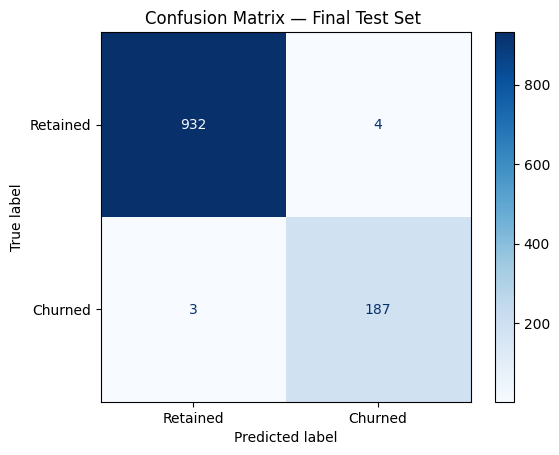

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Final Test Set ')
plt.show()

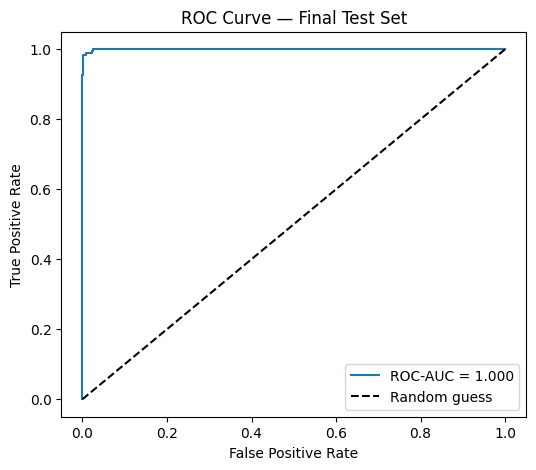

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_pred_proba):.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final Test Set')
plt.legend()
plt.show()

## ROC Curve — Final Test Set (ROC-AUC = 1.000, rounded from 0.9996)

Note: this curve reflects the held-out test set discussed in the "Investigating
the Test Score" section above. The cross-validated ROC-AUC (0.973-0.977) is
reported as the more representative estimate of real-world performance.

# Stage 9: Final Model Serialization & Export

To deploy the champion Tuned Gradient Boosting model into a functional backend service (Stage 9),
the refitted estimator and its feature signature are exported using joblib.


In [ ]:
import joblib

# Export the tuned Gradient Boosting pipeline and input feature columns
joblib.dump(best_gb, "churn_model.joblib")
joblib.dump(list(X_train.columns), "model_features.joblib")
print("Final model exported successfully as churn_model.joblib!")
print(f"Exported feature signature count: {len(X_train.columns)} features")
